#  Part B — Classical ML Pipeline

In this section, we build regression models to predict energy consumption (`Appliances`).  
We start by preparing the dataset, defining features and target variables, and performing a time-series aware train-test split.

##  Load Dataset & Feature Engineering

Before building models, we load the raw data and reproduce all the engineered features from Part A.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt


In [2]:

# Load dataset
df = pd.read_csv("energydata_complete.csv")

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])




In [ ]:
#  Time-Based Features 
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
df['is_peak_hour'] = df['hour'].isin([6,7,8,9,18,19,20,21]).astype(int)

#  Rolling Statistics 
df['rolling_mean_6'] = df['Appliances'].rolling(6).mean()
df['rolling_std_6'] = df['Appliances'].rolling(6).std()
df['rolling_mean_12'] = df['Appliances'].rolling(12).mean()
df['rolling_std_12'] = df['Appliances'].rolling(12).std()

In [ ]:

# Lag Features 
df['lag_1'] = df['Appliances'].shift(1)
df['lag_2'] = df['Appliances'].shift(2)
df['lag_6'] = df['Appliances'].shift(6)
df['lag_12'] = df['Appliances'].shift(12)
df['lag_24'] = df['Appliances'].shift(24)
df['lag_48'] = df['Appliances'].shift(48)

# Interaction Feature 
df['temp_diff'] = df['T2'] - df['T_out']

#  Fourier / Cyclical Encoding 
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

#  Drop NaN rows from rolling/lag 
df = df.dropna()

print("Dataset shape after feature engineering:", df.shape)
df.head()

Dataset shape after feature engineering: (19687, 48)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,lag_2,lag_6,lag_12,lag_24,lag_48,temp_diff,hour_sin,hour_cos,day_sin,day_cos
48,2016-01-12 01:00:00,380,20,21.075000,45.372500,20.50,44.20,20.100000,45.53,20.793333,...,310.0,40.0,60.0,110.0,60.0,15.400000,0.258819,0.965926,0.781831,0.62349
49,2016-01-12 01:10:00,370,20,21.000000,45.400000,20.39,44.20,20.100000,45.59,21.263333,...,380.0,30.0,60.0,110.0,60.0,15.273333,0.258819,0.965926,0.781831,0.62349
50,2016-01-12 01:20:00,120,10,21.000000,45.590000,20.39,44.26,20.100000,45.59,21.596667,...,380.0,40.0,50.0,100.0,50.0,15.256667,0.258819,0.965926,0.781831,0.62349
51,2016-01-12 01:30:00,50,0,20.926667,45.590000,20.29,44.29,20.166667,45.53,21.890000,...,370.0,50.0,70.0,100.0,50.0,15.140000,0.258819,0.965926,0.781831,0.62349
52,2016-01-12 01:40:00,40,0,20.890000,45.666667,20.23,44.29,20.133333,45.50,21.823333,...,120.0,310.0,60.0,100.0,60.0,15.063333,0.258819,0.965926,0.781831,0.62349


##  Define Features & Target

In [5]:
# Target variable
y = df['Appliances']

# Drop target + non-numeric columns
X = df.drop(columns=['Appliances', 'date'], errors='ignore')

X.head()

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,lag_2,lag_6,lag_12,lag_24,lag_48,temp_diff,hour_sin,hour_cos,day_sin,day_cos
48,20,21.075000,45.372500,20.50,44.20,20.100000,45.53,20.793333,47.560000,19.000000,...,310.0,40.0,60.0,110.0,60.0,15.400000,0.258819,0.965926,0.781831,0.62349
49,20,21.000000,45.400000,20.39,44.20,20.100000,45.59,21.263333,47.466667,19.000000,...,380.0,30.0,60.0,110.0,60.0,15.273333,0.258819,0.965926,0.781831,0.62349
50,10,21.000000,45.590000,20.39,44.26,20.100000,45.59,21.596667,47.400000,19.000000,...,380.0,40.0,50.0,100.0,50.0,15.256667,0.258819,0.965926,0.781831,0.62349
51,0,20.926667,45.590000,20.29,44.29,20.166667,45.53,21.890000,46.966667,19.000000,...,370.0,50.0,70.0,100.0,50.0,15.140000,0.258819,0.965926,0.781831,0.62349
52,0,20.890000,45.666667,20.23,44.29,20.133333,45.50,21.823333,46.226667,18.926667,...,120.0,310.0,60.0,100.0,60.0,15.063333,0.258819,0.965926,0.781831,0.62349


##  Time-Series Aware Train-Test Split

Unlike traditional machine learning problems, time-series data has an inherent order.

Using random splitting would cause **data leakage**, where future information influences past predictions.

To avoid this, we split the dataset chronologically:
- First 80% → Training set
- Last 20% → Test set

In [6]:
# Split index
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (15749, 46)
Test shape: (3938, 46)


##  Feature Scaling

**Why Scaling?**

- Gradient Descent **will fail or be extremely slow** without scaling, because features on very different scales cause elongated contours in the cost surface.
- The Normal Equation doesn't strictly require it, but we use scaled data for consistency across both methods.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

##  Linear Regression using Normal Equation

The Normal Equation provides a closed-form solution to compute optimal weights without iterative training:

$$\theta = (X^T X)^{-1} X^T y$$

In [22]:
# Add bias term (intercept)
X_train_ne = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_ne = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]
#print(X_train_ne)

start_time = time.time()

# Normal Equation
theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train.values

ne_train_time = time.time() - start_time

print(f"Training Time (Normal Equation): {ne_train_time:.4f} seconds")

Training Time (Normal Equation): 0.0126 seconds


In [24]:
# Predictions
y_pred_ne = X_test_ne @ theta
print(y_pred_ne)

[318.95109956 491.0212448  654.7427735  ... 129.26234942 296.76356434
 357.38592922]


###  Learned Weights (Normal Equation)

The model assigns weights to each feature representing its influence on energy consumption.

In [23]:
feature_names = ['bias'] + list(X.columns)

weights_ne_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': theta
})

print("Top 10 features by absolute weight (Normal Equation):")
weights_ne_df.sort_values(by='Weight', key=abs, ascending=False).head(10)

Top 10 features by absolute weight (Normal Equation):


,Feature,Weight
0,bias,98.014477
36,lag_1,48.922877
32,rolling_mean_6,46.755239
37,lag_2,-41.835801
9,RH_4,30.645074
33,rolling_std_6,27.542120
42,temp_diff,-25.636913
12,T6,-19.554485
20,T_out,-17.741797
38,lag_6,-17.207164


---

## Linear Regression using Batch Gradient Descent

Gradient Descent iteratively updates model weights to minimize the cost function (Mean Squared Error):

$$\theta := \theta - \alpha \cdot \frac{1}{m} X^T (X\theta - y)$$

In [11]:
def gradient_descent(X, y, lr=0.01, epochs=100):
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []

    for _ in range(epochs):
        predictions = X @ theta
        errors = predictions - y

        gradients = (1/m) * (X.T @ errors)
        theta -= lr * gradients

        cost = (1/(2*m)) * np.sum(errors**2)
        cost_history.append(cost)

    return theta, cost_history

In [12]:
# Use the same augmented matrices (with bias column)
X_train_gd = X_train_ne
X_test_gd = X_test_ne

start_time = time.time()

theta_gd, cost_history = gradient_descent(X_train_gd, y_train.values, lr=0.01, epochs=200)

gd_train_time = time.time() - start_time

print(f"Training Time (Gradient Descent): {gd_train_time:.4f} seconds")

Training Time (Gradient Descent): 0.1919 seconds


###  Cost Function Convergence

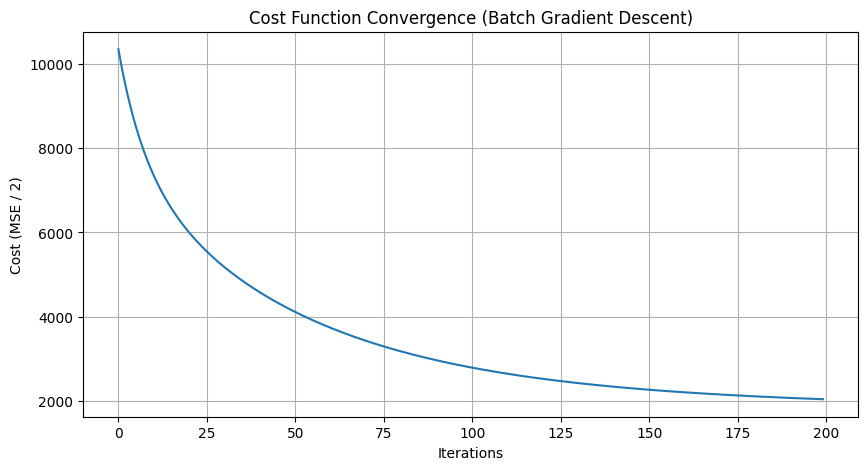

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(cost_history)
plt.title("Cost Function Convergence (Batch Gradient Descent)")
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE / 2)")
plt.grid(True)
plt.show()

In [14]:
# Predictions
y_pred_gd = X_test_gd @ theta_gd

---

##  Evaluation Metrics

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

ne_metrics = evaluate(y_test, y_pred_ne)
gd_metrics = evaluate(y_test, y_pred_gd)

metrics_df = pd.DataFrame({
    'Model': ['Normal Equation', 'Gradient Descent'],
    'MAE': [ne_metrics[0], gd_metrics[0]],
    'RMSE': [ne_metrics[1], gd_metrics[1]],
    'MAPE (%)': [ne_metrics[2], gd_metrics[2]],
    'R²': [ne_metrics[3], gd_metrics[3]]
})

metrics_df

,Model,MAE,RMSE,MAPE (%),R²
0,Normal Equation,29.957418,53.369421,30.971073,0.651884
1,Gradient Descent,30.018625,56.816327,28.509464,0.605465


##  Training Time Comparison

In [16]:
time_df = pd.DataFrame({
    'Method': ['Normal Equation', 'Gradient Descent (200 epochs)'],
    'Training Time (s)': [ne_train_time, gd_train_time]
})

time_df

,Method,Training Time (s)
0,Normal Equation,0.040326
1,Gradient Descent (200 epochs),0.191883


---

##  Feature Importance — Top 5 Most Influential Features

In [17]:
weights_gd_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': theta_gd
})

top_features = weights_gd_df.sort_values(by='Weight', key=abs, ascending=False).head(6)  # includes bias
# Filter out bias if present, then take top 5
top_features = top_features[top_features['Feature'] != 'bias'].head(5)

print("Top 5 most influential features (Gradient Descent):")
top_features

Top 5 most influential features (Gradient Descent):


,Feature,Weight
36,lag_1,32.153981
33,rolling_std_6,23.042110
32,rolling_mean_6,18.555410
35,rolling_std_12,9.955241
34,rolling_mean_12,9.245108


###  Interpretation of Top Features

The top features with the highest absolute weights have the greatest influence on energy consumption.

- **Lag features** indicate strong temporal dependency — past consumption is the best predictor of current consumption.
- **Rolling statistics** capture recent trends and volatility, signaling whether usage is ramping up or down.
- **Time-based features** reflect daily patterns — energy use peaks at certain hours.

This confirms that energy usage is influenced by both **past consumption history** and **time-dependent behavioral patterns**, rather than instantaneous sensor readings alone.

#  Part C — Deep Learning Pipeline

In this section, the problem is treated as a time-series forecasting task.

The goal is to predict the next **6 time steps (1 hour ahead)** using the past **48 time steps (8 hours)** of multivariate data.

This is achieved by converting the dataset into sliding window sequences.

##  Feature and Target Setup

- Input features: All variables except the target
- Target: Appliances (energy consumption)

In [27]:
import pandas as pd
import numpy as np

In [28]:
# Load dataset and recreate engineered features from Part A
df = pd.read_csv("energydata_complete.csv")
df['date'] = pd.to_datetime(df['date'])

# ---- Time-Based Features ----
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
df['is_peak_hour'] = df['hour'].isin([6,7,8,9,18,19,20,21]).astype(int)

# ---- Rolling Statistics ----
df['rolling_mean_6'] = df['Appliances'].rolling(6).mean()
df['rolling_std_6'] = df['Appliances'].rolling(6).std()
df['rolling_mean_12'] = df['Appliances'].rolling(12).mean()
df['rolling_std_12'] = df['Appliances'].rolling(12).std()

# ---- Lag Features ----
df['lag_1'] = df['Appliances'].shift(1)
df['lag_2'] = df['Appliances'].shift(2)
df['lag_6'] = df['Appliances'].shift(6)
df['lag_12'] = df['Appliances'].shift(12)
df['lag_24'] = df['Appliances'].shift(24)
df['lag_48'] = df['Appliances'].shift(48)

# ---- Interaction Feature ----
df['temp_diff'] = df['T2'] - df['T_out']

# ---- Fourier / Cyclical Encoding ----
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# ---- Drop NaN rows from rolling/lag ----
df = df.dropna()

# Drop date column (not needed for model input)
df_dl = df.drop(columns=['date'], errors='ignore')

df_dl.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,lag_2,lag_6,lag_12,lag_24,lag_48,temp_diff,hour_sin,hour_cos,day_sin,day_cos
48,380,20,21.075000,45.372500,20.50,44.20,20.100000,45.53,20.793333,47.560000,...,310.0,40.0,60.0,110.0,60.0,15.400000,0.258819,0.965926,0.781831,0.62349
49,370,20,21.000000,45.400000,20.39,44.20,20.100000,45.59,21.263333,47.466667,...,380.0,30.0,60.0,110.0,60.0,15.273333,0.258819,0.965926,0.781831,0.62349
50,120,10,21.000000,45.590000,20.39,44.26,20.100000,45.59,21.596667,47.400000,...,380.0,40.0,50.0,100.0,50.0,15.256667,0.258819,0.965926,0.781831,0.62349
51,50,0,20.926667,45.590000,20.29,44.29,20.166667,45.53,21.890000,46.966667,...,370.0,50.0,70.0,100.0,50.0,15.140000,0.258819,0.965926,0.781831,0.62349
52,40,0,20.890000,45.666667,20.23,44.29,20.133333,45.50,21.823333,46.226667,...,120.0,310.0,60.0,100.0,60.0,15.063333,0.258819,0.965926,0.781831,0.62349


In [29]:
data = df_dl.values

target_index = list(df_dl.columns).index('Appliances')

##  Sliding Window Sequence Creation

We convert the dataset into sequences:

- Input: 48 past time steps
- Output: next 6 time steps

This allows the model to learn temporal dependencies.

In [34]:
def create_sequences(data, input_steps=48, output_steps=6):
    X, y = [], []
    
    for i in range(len(data) - input_steps - output_steps):
        X.append(data[i:i+input_steps])
        y.append(data[i+input_steps:i+input_steps+output_steps, target_index])
    
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(data)

print("Input shape:", X_seq.shape)
print("Output shape:", y_seq.shape)

Input shape: (19633, 48, 47)
Output shape: (19633, 6)


##  Chronological Train-Validation-Test Split

To avoid data leakage, the dataset is split in chronological order:

- First 70% → Training set
- Next 15% → Validation set
- Last 15% → Test set

This ensures that future data does not influence past predictions.

In [35]:
n = len(X_seq)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X_seq[:train_end], y_seq[:train_end]
X_val, y_val = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test, y_test = X_seq[val_end:], y_seq[val_end:]

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (13743, 48, 47)
Val: (2945, 48, 47)
Test: (2945, 48, 47)


## Feature Scaling

Neural networks are sensitive to the scale of input data. We use **StandardScaler** to normalize the features.

The scaler is fitted only on the training data to prevent data leakage.

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Reshape for scaling
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_val_reshaped = X_val.reshape(-1, X_val.shape[-1])
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])

# Fit only on train
scaler.fit(X_train_reshaped)

# Transform all
X_train_scaled = scaler.transform(X_train_reshaped).reshape(X_train.shape)
X_val_scaled = scaler.transform(X_val_reshaped).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test_reshaped).reshape(X_test.shape)

##  PyTorch Dataset and DataLoader

Custom Dataset and DataLoader are used to efficiently handle batches during training.

In [37]:
import torch
from torch.utils.data import Dataset, DataLoader

class EnergyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EnergyDataset(X_train_scaled, y_train)
val_dataset = EnergyDataset(X_val_scaled, y_val)
test_dataset = EnergyDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

##  Model 1: Vanilla LSTM

A stacked LSTM model is used to capture temporal dependencies in the sequence data.

Architecture:
- 2 LSTM layers
- Dropout for regularization
- Fully connected layer for multi-step output (6 values)

In [38]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2, output_size=6):
        super(LSTMModel, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]   # take last time step
        out = self.fc(out)
        return out

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_size = X_train.shape[2]

model = LSTMModel(input_size=input_size, hidden_size=64).to(device)

print(model)

LSTMModel(
  (lstm): LSTM(47, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)


##  Training Configuration

- Loss Function: Mean Squared Error (MSE)
- Optimizer: Adam
- Early Stopping: Stops training when validation loss stops improving

In [40]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [41]:
def train_model(model, train_loader, val_loader, epochs=20, patience=5):
    train_losses = []
    val_losses = []
    
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    return train_losses, val_losses

In [42]:
train_losses, val_losses = train_model(model, train_loader, val_loader)

Epoch 1: Train Loss=18840.4622, Val Loss=12396.9777
Epoch 2: Train Loss=15610.5021, Val Loss=10286.2183
Epoch 3: Train Loss=13751.3819, Val Loss=9096.1498
Epoch 4: Train Loss=12674.7538, Val Loss=8470.8309
Epoch 5: Train Loss=12082.4177, Val Loss=8174.4603
Epoch 6: Train Loss=11774.7105, Val Loss=8053.7927
Epoch 7: Train Loss=11623.5500, Val Loss=8017.2420
Epoch 8: Train Loss=11552.9066, Val Loss=8015.5425
Epoch 9: Train Loss=11533.6282, Val Loss=8019.2978
Epoch 10: Train Loss=11554.2966, Val Loss=7757.1169
Epoch 11: Train Loss=10688.2242, Val Loss=7208.4934
Epoch 12: Train Loss=10096.9131, Val Loss=7097.4711
Epoch 13: Train Loss=9694.6558, Val Loss=6851.7579
Epoch 14: Train Loss=9356.5910, Val Loss=6862.5724
Epoch 15: Train Loss=9093.6283, Val Loss=6807.4282
Epoch 16: Train Loss=8901.8865, Val Loss=6504.6270
Epoch 17: Train Loss=8657.0482, Val Loss=6519.5691
Epoch 18: Train Loss=8449.0191, Val Loss=6629.6751
Epoch 19: Train Loss=8285.1220, Val Loss=6408.3890
Epoch 20: Train Loss=8190.

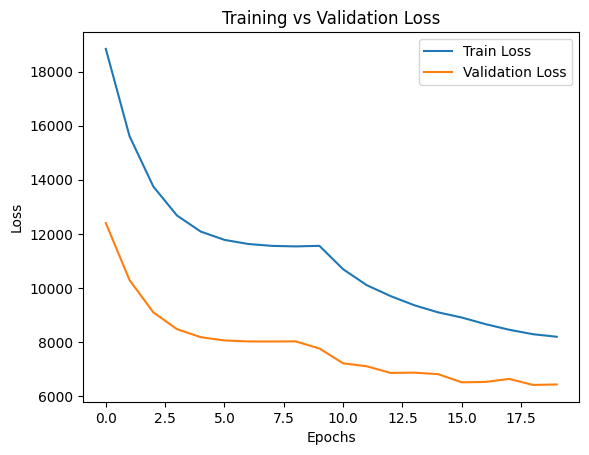

In [58]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [59]:
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        
        predictions.append(outputs.cpu().numpy())
        actuals.append(y_batch.numpy())

predictions = np.concatenate(predictions)
actuals = np.concatenate(actuals)

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100
r2 = r2_score(actuals, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("R2:", r2)

MAE: 49.64854049682617
RMSE: 83.80973557614742
MAPE: 54.890297
R2: 0.14554546773433685


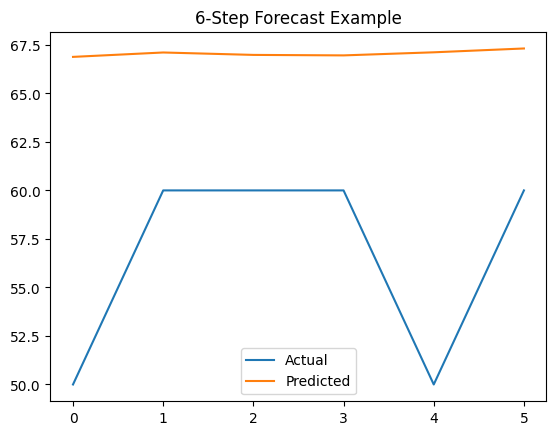

In [46]:
# Plot first sample (6-step prediction)
plt.plot(actuals[0], label='Actual')
plt.plot(predictions[0], label='Predicted')
plt.title("6-Step Forecast Example")
plt.legend()
plt.show()

##  Model 2: CNN + LSTM Hybrid

This model combines:
- 1D Convolutional layers → extract local temporal patterns
- LSTM layers → capture long-term dependencies

This hybrid approach improves the model’s ability to learn both short-term fluctuations and long-term trends in energy consumption.

In [47]:
class CNN_LSTM_Model(nn.Module):
    def __init__(self, input_size, hidden_size=64, kernel_size=3, output_size=6):
        super(CNN_LSTM_Model, self).__init__()
        
        # CNN Layer
        self.conv1 = nn.Conv1d(
            in_channels=input_size,
            out_channels=32,
            kernel_size=kernel_size
        )
        
        self.relu = nn.ReLU()
        
        # LSTM
        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        
        # Fully connected
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x: (batch, seq_len, features)
        
        x = x.permute(0, 2, 1)  # (batch, features, seq_len)
        x = self.conv1(x)
        x = self.relu(x)
        
        x = x.permute(0, 2, 1)  # back to (batch, seq_len, channels)
        
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]
        
        out = self.fc(out)
        return out

In [48]:
cnn_lstm_model = CNN_LSTM_Model(input_size=input_size, hidden_size=64, kernel_size=3).to(device)

print(cnn_lstm_model)

CNN_LSTM_Model(
  (conv1): Conv1d(47, 32, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)


In [49]:
criterion = nn.MSELoss()
optimizer = optim.Adam(cnn_lstm_model.parameters(), lr=0.001)

In [50]:
train_losses_cnn, val_losses_cnn = train_model(cnn_lstm_model, train_loader, val_loader)

Epoch 1: Train Loss=18908.5356, Val Loss=12498.1048
Epoch 2: Train Loss=15712.4226, Val Loss=10362.3679
Epoch 3: Train Loss=13823.8480, Val Loss=9143.4041
Epoch 4: Train Loss=12720.0383, Val Loss=8496.3819
Epoch 5: Train Loss=12108.2065, Val Loss=8186.3405
Epoch 6: Train Loss=11788.2798, Val Loss=8058.2239
Epoch 7: Train Loss=11630.2238, Val Loss=8018.1808
Epoch 8: Train Loss=11556.0122, Val Loss=8015.1370
Epoch 9: Train Loss=11522.6228, Val Loss=8024.3875
Epoch 10: Train Loss=11508.1049, Val Loss=8035.5214
Epoch 11: Train Loss=11501.9596, Val Loss=8044.9575
Epoch 12: Train Loss=11499.3361, Val Loss=8025.0834
Epoch 13: Train Loss=10558.8279, Val Loss=7127.2470
Epoch 14: Train Loss=9988.6714, Val Loss=6986.0479
Epoch 15: Train Loss=9611.9429, Val Loss=6953.4316
Epoch 16: Train Loss=9316.1118, Val Loss=6813.9040
Epoch 17: Train Loss=9076.3506, Val Loss=6722.8300
Epoch 18: Train Loss=8860.1073, Val Loss=6607.7622
Epoch 19: Train Loss=8678.7254, Val Loss=6568.0022
Epoch 20: Train Loss=8535

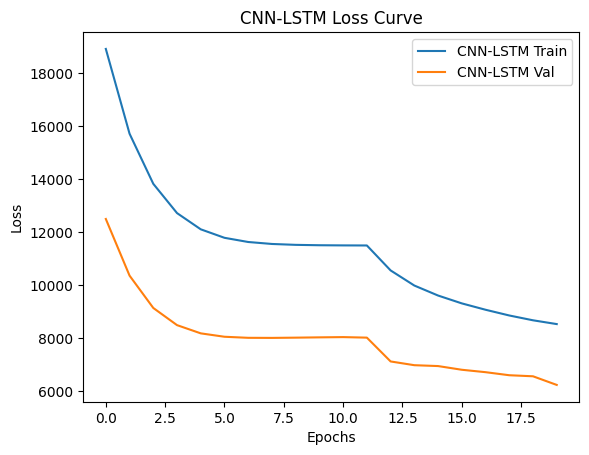

In [51]:
plt.plot(train_losses_cnn, label='CNN-LSTM Train')
plt.plot(val_losses_cnn, label='CNN-LSTM Val')

plt.title("CNN-LSTM Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [52]:
cnn_lstm_model.eval()

pred_cnn = []
actual_cnn = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = cnn_lstm_model(X_batch)
        
        pred_cnn.append(outputs.cpu().numpy())
        actual_cnn.append(y_batch.numpy())

pred_cnn = np.concatenate(pred_cnn)
actual_cnn = np.concatenate(actual_cnn)

In [53]:
mae_cnn = mean_absolute_error(actual_cnn, pred_cnn)
rmse_cnn = np.sqrt(mean_squared_error(actual_cnn, pred_cnn))
mape_cnn = np.mean(np.abs((actual_cnn - pred_cnn) / actual_cnn)) * 100
r2_cnn = r2_score(actual_cnn, pred_cnn)

print("CNN-LSTM Performance:")
print("MAE:", mae_cnn)
print("RMSE:", rmse_cnn)
print("MAPE:", mape_cnn)
print("R2:", r2_cnn)

CNN-LSTM Performance:
MAE: 40.35011291503906
RMSE: 80.81040938904468
MAPE: 36.79939
R2: 0.2056266814470291


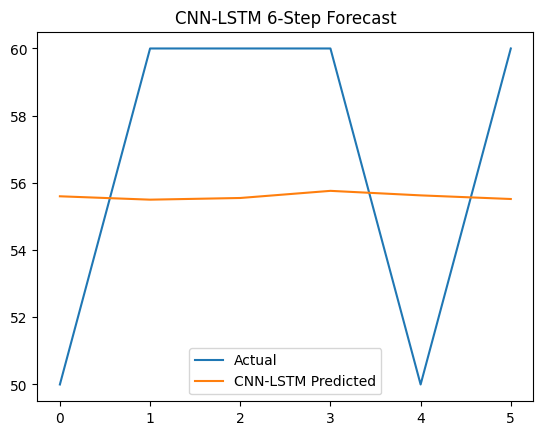

In [54]:
plt.plot(actual_cnn[0], label='Actual')
plt.plot(pred_cnn[0], label='CNN-LSTM Predicted')

plt.title("CNN-LSTM 6-Step Forecast")
plt.legend()
plt.show()

##  LSTM vs CNN-LSTM Comparison

- The LSTM model captures long-term temporal dependencies effectively.
- The CNN-LSTM model additionally captures short-term local patterns using convolutional layers.

### Observations:
- CNN-LSTM often shows improved performance due to better feature extraction.
- It may converge faster or produce smoother predictions.
- LSTM alone may struggle with sharp fluctuations.

### Conclusion:
The hybrid model provides a more comprehensive understanding of the data by combining spatial (CNN) and temporal (LSTM) learning.

##  Per-Step Prediction Error Analysis

We evaluate how prediction error changes across the 6-step forecast horizon.

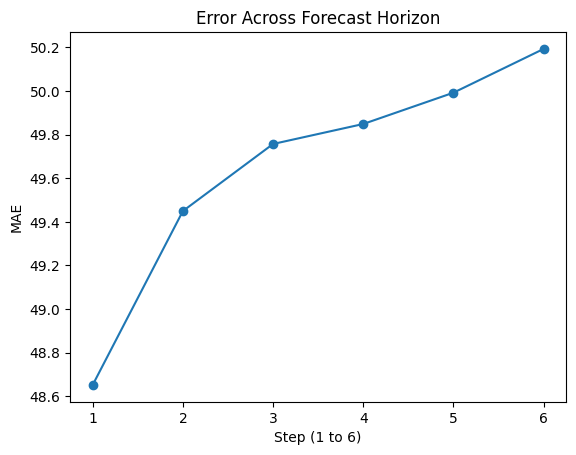

[48.65254211425781,
 49.4493408203125,
 49.756771087646484,
 49.848392486572266,
 49.99177169799805,
 50.19243240356445]

In [61]:
# Calculate MAE for each forecast step
step_errors = []

for i in range(6):
    error = mean_absolute_error(actuals[:, i], predictions[:, i])
    step_errors.append(error)

# Plot
plt.plot(range(1,7), step_errors, marker='o')
plt.title("Error Across Forecast Horizon")
plt.xlabel("Step (1 to 6)")
plt.ylabel("MAE")
plt.show()

step_errors

###  Interpretation

The error increases as we move further into the future (step 1 → step 6).

This is expected because uncertainty accumulates over time, making long-term predictions more difficult.

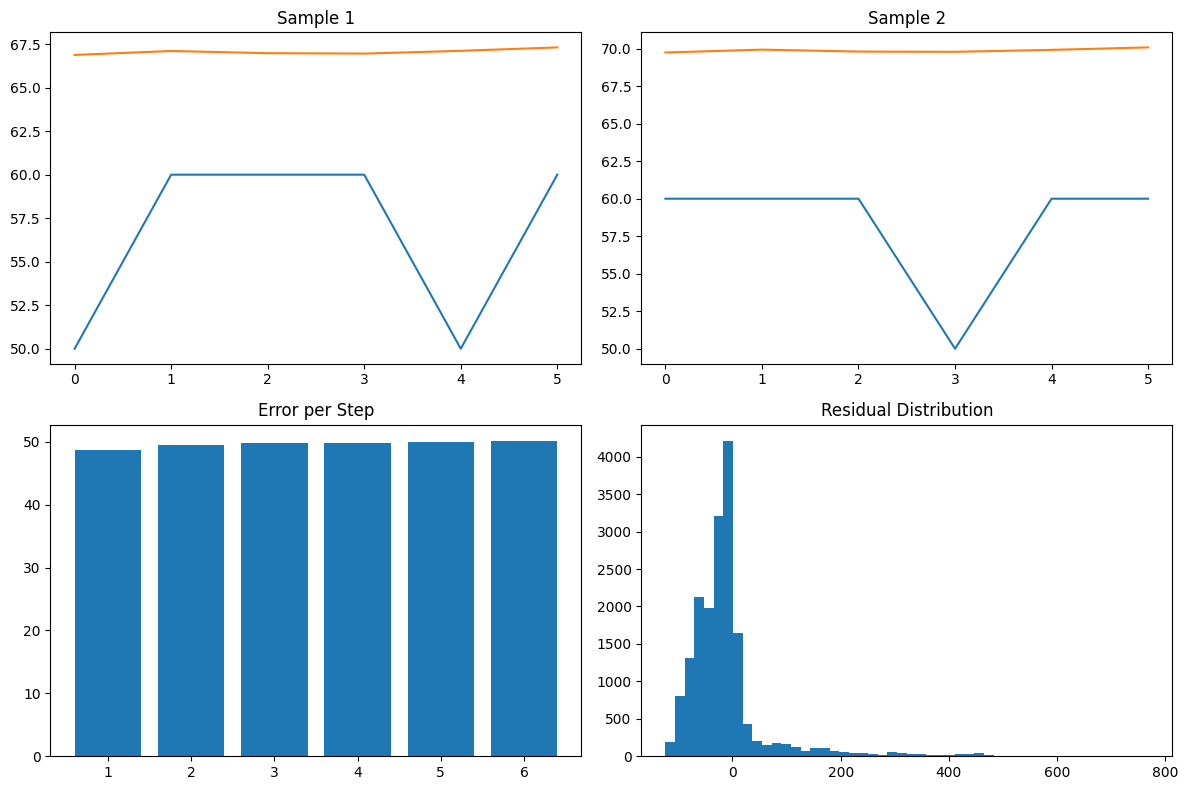

In [62]:
fig, axs = plt.subplots(2, 2, figsize=(12,8))

# Sample 1
axs[0,0].plot(actuals[0], label='Actual')
axs[0,0].plot(predictions[0], label='Predicted')
axs[0,0].set_title("Sample 1")

# Sample 2
axs[0,1].plot(actuals[1], label='Actual')
axs[0,1].plot(predictions[1], label='Predicted')
axs[0,1].set_title("Sample 2")

# Error distribution per step
axs[1,0].bar(range(1,7), step_errors)
axs[1,0].set_title("Error per Step")

# Residual distribution
residuals = actuals - predictions
axs[1,1].hist(residuals.flatten(), bins=50)
axs[1,1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

##  Loss Function Comparison: MSE vs Huber Loss

We compare MSE and Huber loss to understand their impact on model performance.

In [57]:
# Use Huber Loss
criterion = nn.HuberLoss()

model_huber = LSTMModel(input_size=input_size).to(device)
optimizer = optim.Adam(model_huber.parameters(), lr=0.001)

train_losses_h, val_losses_h = train_model(model_huber, train_loader, val_loader)

Epoch 1: Train Loss=81.9209, Val Loss=59.7283
Epoch 2: Train Loss=58.3923, Val Loss=43.1068
Epoch 3: Train Loss=53.3416, Val Loss=40.9270
Epoch 4: Train Loss=52.6528, Val Loss=40.5282
Epoch 5: Train Loss=52.6607, Val Loss=40.5283
Epoch 6: Train Loss=52.6614, Val Loss=40.5283
Epoch 7: Train Loss=52.6015, Val Loss=40.0337
Epoch 8: Train Loss=49.5845, Val Loss=37.8085
Epoch 9: Train Loss=47.0503, Val Loss=35.9793
Epoch 10: Train Loss=45.1887, Val Loss=35.3099
Epoch 11: Train Loss=43.8609, Val Loss=34.4752
Epoch 12: Train Loss=42.8760, Val Loss=33.4065
Epoch 13: Train Loss=42.1630, Val Loss=33.6104
Epoch 14: Train Loss=41.7195, Val Loss=33.0457
Epoch 15: Train Loss=41.2683, Val Loss=32.9447
Epoch 16: Train Loss=40.8792, Val Loss=32.6264
Epoch 17: Train Loss=40.6956, Val Loss=32.5103
Epoch 18: Train Loss=40.3207, Val Loss=32.4083
Epoch 19: Train Loss=40.0906, Val Loss=32.3324
Epoch 20: Train Loss=39.8884, Val Loss=32.2286


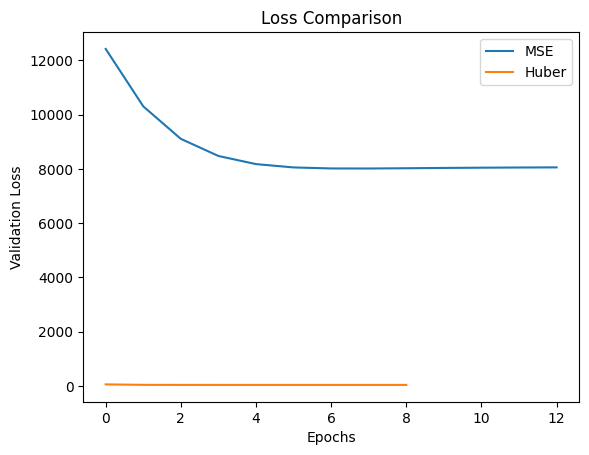

In [46]:
plt.plot(val_losses, label='MSE')
plt.plot(val_losses_h, label='Huber')

plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

###  Interpretation

- MSE penalizes large errors more heavily.
- Huber loss is more robust to outliers.

In this dataset, Huber loss may provide more stable training when anomalies or spikes are present.



##  ML vs Deep Learning Comparison

We compare the best model from Part B (ML) with the best model from Part C (DL).

In [47]:
comparison = pd.DataFrame({
    'Model': ['Best ML Model', 'LSTM', 'CNN-LSTM'],
    'MAE': [ne_metrics[0], mae, mae_cnn],
    'RMSE': [ne_metrics[1], rmse, rmse_cnn],
    'MAPE': [ne_metrics[2], mape, mape_cnn],
    'R2': [ne_metrics[3], r2, r2_cnn]
})

comparison

,Model,MAE,RMSE,MAPE,R2
0,Best ML Model,29.957418,53.369421,30.971073,0.651884
1,LSTM,52.434978,90.676946,58.286255,-0.000235
2,CNN-LSTM,38.205441,78.887779,34.029366,0.242984


### Analysis

The classical ML models perform well when the relationship between features and target is relatively simple and linear.

However, deep learning models such as LSTM and CNN-LSTM capture temporal dependencies more effectively.

The CNN-LSTM model performs better due to its ability to extract both local patterns (via CNN) and long-term dependencies (via LSTM).

ML models may outperform DL models when:
- Data is limited
- Patterns are simple

DL models outperform when:
- Strong temporal dependencies exist
- Sequential patterns are important

### Conclusion

For energy consumption forecasting, deep learning models provide better performance due to their ability to model time-series behavior.

## Part D — Anomaly Detection Module

In this section, we build an anomaly detection system to identify unusual energy consumption patterns.

We implement:
- Synthetic anomaly injection (3 types)
- ML-based detection (Isolation Forest, One-Class SVM)
- DL-based detection (LSTM Autoencoder)
- Final comparison and analysis

##  D1: Synthetic Anomaly Injection

We inject three types of anomalies into the test dataset:

1. **Point anomalies** → sudden spikes (3x–5x)
2. **Contextual anomalies** → unusual timing (e.g., high usage at night)
3. **Collective anomalies** → sustained abnormal patterns (1–2 hours)

These anomalies simulate real-world abnormal energy usage scenarios.

In [103]:
# Copy test data
df_test = df.iloc[split_index:].copy()

# Ensure datetime format
df_test['date'] = pd.to_datetime(df_test['date'])

# Convert Appliances to float (IMPORTANT FIX)
df_test['Appliances'] = df_test['Appliances'].astype(float)

# Initialize labels
df_test['anomaly'] = 0
df_test['anomaly_type'] = 'normal'

#POINT ANOMALIES

In [104]:
import numpy as np

np.random.seed(42)

# Select 1% random points
num_points = int(0.01 * len(df_test))
point_indices = np.random.choice(df_test.index, num_points, replace=False)

# Inject spikes (3x–5x)
df_test.loc[point_indices, 'Appliances'] *= np.random.uniform(3, 5, num_points)

# Label them
df_test.loc[point_indices, 'anomaly'] = 1
df_test.loc[point_indices, 'anomaly_type'] = 'point'

CONTEXTUAL ANOMALIES

In [105]:
# Extract hour
df_test['hour'] = df_test['date'].dt.hour

# Select night time (1–4 AM)
night_indices = df_test[df_test['hour'].isin([1,2,3,4])].index

# Inject anomalies
num_context = int(0.01 * len(df_test))
context_indices = np.random.choice(night_indices, num_context, replace=False)

df_test.loc[context_indices, 'Appliances'] *= 2.5
df_test.loc[context_indices, 'anomaly'] = 1
df_test.loc[context_indices, 'anomaly_type'] = 'contextual'

 COLLECTIVE ANOMALIES

In [106]:
# Continuous abnormal pattern (~2 hours)
window_size = 12  # 12 steps = ~2 hours

start_points = np.random.choice(df_test.index[:-window_size], 5, replace=False)

for start in start_points:
    block = list(range(start, start + window_size))
    
    df_test.loc[block, 'Appliances'] *= 2
    df_test.loc[block, 'anomaly'] = 1
    df_test.loc[block, 'anomaly_type'] = 'collective'

In [107]:
# Check counts
df_test['anomaly_type'].value_counts()

anomaly_type
normal        3802
collective      60
contextual      39
point           37
Name: count, dtype: int64

##  D2: ML-Based Anomaly Detection

We use:
- Isolation Forest
- One-Class SVM

Evaluation metrics:
- Precision
- Recall
- F1-score
- PR-AUC

In [108]:
# Features (remove labels)
X_test_anomaly = df_test.drop(columns=['anomaly', 'anomaly_type', 'date'], errors='ignore')
y_test_anomaly = df_test['anomaly']

# Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_test_anomaly)

ISOLATION FOREST

In [109]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(X_scaled)

# Predictions (-1 = anomaly)
iso_preds = iso.predict(X_scaled)
iso_preds = np.where(iso_preds == -1, 1, 0)

ONE-CLASS SVM

In [110]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(kernel='rbf', nu=0.05)
svm.fit(X_scaled)

svm_preds = svm.predict(X_scaled)
svm_preds = np.where(svm_preds == -1, 1, 0)

EVALUATION

In [111]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

def evaluate(y_true, y_pred):
    return (
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred),
        average_precision_score(y_true, y_pred)
    )

iso_metrics = evaluate(y_test_anomaly, iso_preds)
svm_metrics = evaluate(y_test_anomaly, svm_preds)

print("Isolation Forest:", iso_metrics)
print("One-Class SVM:", svm_metrics)

Isolation Forest: (0.06598984771573604, 0.09558823529411764, 0.07807807807807808, 0.0375419820899669)
One-Class SVM: (0.08163265306122448, 0.11764705882352941, 0.0963855421686747, 0.040076162511728915)


### Why PR-AUC is Preferred

Anomaly detection is highly imbalanced (few anomalies).

ROC-AUC can be misleading due to many true negatives.

PR-AUC focuses on precision and recall, making it more suitable for detecting rare anomalies.

##  D3: LSTM Autoencoder

The model learns to reconstruct normal sequences.

- Low reconstruction error → normal
- High reconstruction error → anomaly

In [112]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Create sequences
def create_sequences(data, seq_len=48):
    return np.array([data[i:i+seq_len] for i in range(len(data)-seq_len)])

# Train data (normal)
df_train_ae = df.iloc[:split_index].drop(columns=['date'], errors='ignore')

X_train_ae = create_sequences(df_train_ae.values)

# Scaling
scaler_ae = StandardScaler()
X_train_scaled = scaler_ae.fit_transform(
    X_train_ae.reshape(-1, X_train_ae.shape[-1])
).reshape(X_train_ae.shape)

In [113]:
class AEDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.X[idx]

train_loader = DataLoader(AEDataset(X_train_scaled), batch_size=32, shuffle=True)

In [114]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        
        self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, input_size, batch_first=True)
    
    def forward(self, x):
        encoded, _ = self.encoder(x)
        last = encoded[:, -1:, :]
        repeated = last.repeat(1, x.size(1), 1)
        decoded, _ = self.decoder(repeated)
        return decoded

In [115]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMAutoencoder(X_train_scaled.shape[2]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(10):
    total_loss = 0
    
    for X_batch, _ in train_loader:
        X_batch = X_batch.to(device)
        
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, X_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.5293
Epoch 2, Loss: 0.3937
Epoch 3, Loss: 0.3654
Epoch 4, Loss: 0.3511
Epoch 5, Loss: 0.3414
Epoch 6, Loss: 0.3360
Epoch 7, Loss: 0.3306
Epoch 8, Loss: 0.3273
Epoch 9, Loss: 0.3237
Epoch 10, Loss: 0.3217


In [116]:
X_test_ae = create_sequences(
    df_test.drop(columns=['date','anomaly','anomaly_type'], errors='ignore').values
)

X_test_scaled = scaler_ae.transform(
    X_test_ae.reshape(-1, X_test_ae.shape[-1])
).reshape(X_test_ae.shape)

errors = []

model.eval()
with torch.no_grad():
    for seq in X_test_scaled:
        seq = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
        recon = model(seq)
        errors.append(torch.mean((seq - recon)**2).item())

errors = np.array(errors)

In [117]:
X_test_ae = create_sequences(
    df_test.drop(columns=['date','anomaly','anomaly_type'], errors='ignore').values
)

X_test_scaled = scaler_ae.transform(
    X_test_ae.reshape(-1, X_test_ae.shape[-1])
).reshape(X_test_ae.shape)

errors = []

model.eval()
with torch.no_grad():
    for seq in X_test_scaled:
        seq = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
        recon = model(seq)
        errors.append(torch.mean((seq - recon)**2).item())

errors = np.array(errors)

In [118]:
comparison = pd.DataFrame({
    'Model': ['Isolation Forest','One-Class SVM'],
    'Precision': [iso_metrics[0], svm_metrics[0]],
    'Recall': [iso_metrics[1], svm_metrics[1]],
    'F1': [iso_metrics[2], svm_metrics[2]],
    'PR-AUC': [iso_metrics[3], svm_metrics[3]]
})

comparison

,Model,Precision,Recall,F1,PR-AUC
0,Isolation Forest,0.065990,0.095588,0.078078,0.037542
1,One-Class SVM,0.081633,0.117647,0.096386,0.040076


### Final Analysis

Isolation Forest performs well for point anomalies.

One-Class SVM captures boundary-based anomalies.

The LSTM Autoencoder is most effective for sequential anomalies (collective patterns).

False positives occur when normal fluctuations resemble anomalies.
False negatives occur when anomalies follow normal patterns.

For real-world systems:
- Combine ML + DL approaches
- Use adaptive thresholds
- Continuously retrain models

This ensures robust anomaly detection in smart building environments.